Import statements

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr
from metpy.units import units

## List data

In [2]:
start = 2004
stop = 2023

name_list_ensmean_cf = [
    f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_JASO/{yr}_ensmean_JASO_counterfactual_raw.nc"
    for yr in range(start, stop + 1)
]

name_mean_reanalysis = [
    "/glade/work/smhenry/NeuralGCM/data/NOAA-CIRES-DOE_20thcentury/1850-1870_mean_JASO_zonal-mean_t_u.nc"
]

In [20]:
cf_dat = []
for i in range(len(name_list_ensmean_cf)):
    cf = xr.open_dataset(name_list_ensmean_cf[i]).sel(level=slice(100,1000))
    cf_dat.append(cf)

cf_years = xr.concat(cf_dat, dim="year")

re_dat = xr.open_mfdataset(name_mean_reanalysis).sel(isobaricInhPa=slice(1000,100))

In [21]:
cf_zonal_mean = cf_years.mean(dim=["longitude", "year"])
re_zonal_mean = re_dat

In [22]:
cf_zonal_mean

<xarray.Dataset> Size: 99kB
Dimensions:                              (level: 27, latitude: 128)
Coordinates:
  * level                                (level) int64 216B 100 125 ... 975 1000
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    temperature                          (level, latitude) float32 14kB 190.5...
    specific_cloud_ice_water_content     (level, latitude) float32 14kB 7.061...
    geopotential                         (level, latitude) float32 14kB 1.419...
    specific_cloud_liquid_water_content  (level, latitude) float32 14kB 5.42e...
    v_component_of_wind                  (level, latitude) float32 14kB -0.06...
    specific_humidity                    (level, latitude) float32 14kB 1.436...
    surface_pressure                     (latitude) float32 512B 7.029e+04 .....
    u_component_of_wind                  (level, latitude) float32 14kB 0.561...
    sim_time                             float64 8B 1.618e+05

In [23]:
re_zonal_mean

<xarray.Dataset> Size: 45kB
Dimensions:        (isobaricInhPa: 21, latitude: 256)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 168B 1e+03 975.0 ... 150.0 100.0
  * latitude       (latitude) float64 2kB 89.46 88.77 88.07 ... -88.77 -89.46
Data variables:
    t              (isobaricInhPa, latitude) float32 22kB dask.array<chunksize=(21, 256), meta=np.ndarray>
    u              (isobaricInhPa, latitude) float32 22kB dask.array<chunksize=(21, 256), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP 
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP 
    history:                 2022-02-13T15:11:19 GRIB to CDM+CF via cfgrib-0....
    DOI:                     10.5065/H93G-WS83
    RDA-Curation-Repo:       https://github.com/NCAR/rda-dataset-curation/tre...

In [24]:
lats = cf_zonal_mean.latitude.values
plevs = cf_zonal_mean.level.values

re_lats  = re_zonal_mean.latitude.values
re_plevs = re_zonal_mean.isobaricInhPa.values

from scipy.interpolate import RegularGridInterpolator

def interp_re_to_cf(re_field, re_lats, re_plevs, cf_lats, cf_plevs):
    """Interpolate reanalysis (re) onto the cf lat/lev grid."""
    interp = RegularGridInterpolator(
        (re_plevs, re_lats), re_field,
        method="linear", bounds_error=False, fill_value=np.nan
    )
    cf_plevs_grid, cf_lats_grid = np.meshgrid(cf_plevs, cf_lats, indexing="ij")
    pts = np.column_stack([cf_plevs_grid.ravel(), cf_lats_grid.ravel()])
    return interp(pts).reshape(len(cf_plevs), len(cf_lats))

cf_t  = cf_zonal_mean["temperature"].values    # shape (lev, lat)
cf_u  = cf_zonal_mean["u_component_of_wind"].values
re_t_raw = re_zonal_mean["t"].values
re_u_raw = re_zonal_mean["u"].values

re_t = interp_re_to_cf(re_t_raw, re_lats, re_plevs, lats, plevs)
re_u = interp_re_to_cf(re_u_raw, re_lats, re_plevs, lats, plevs)

diff_t = cf_t - re_t
diff_u = cf_u - re_u

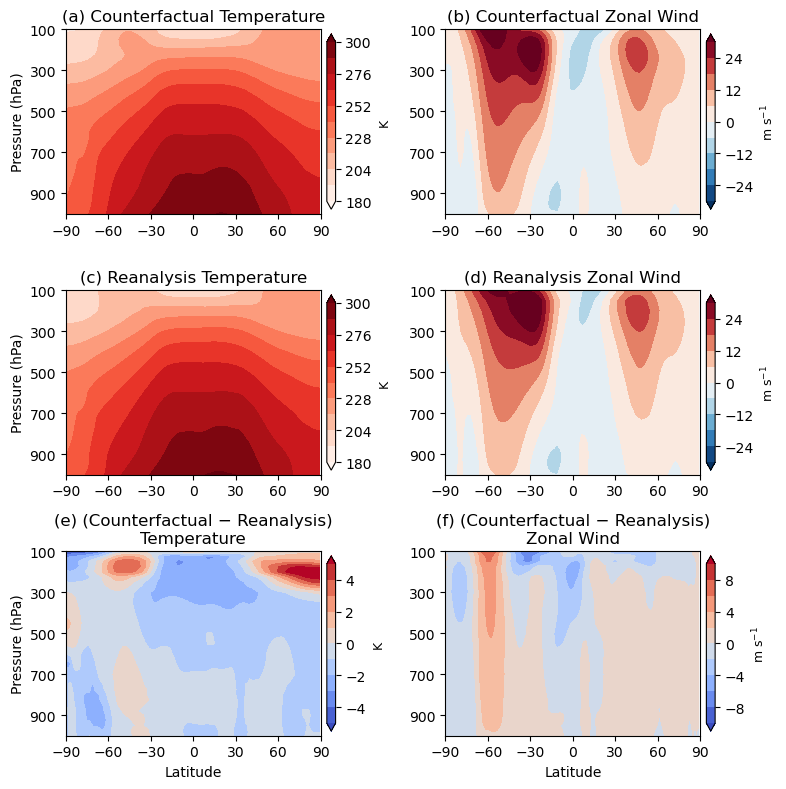

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))

# t_levels = np.linspace(min(cf_t.min(), re_t.min()), max(cf_t.max(), re_t.max()), 11)
# u_levels = np.linspace(min(cf_u.min(), re_u.min()), max(cf_u.max(), re_u.max()), 11)
t_levels = np.linspace(180,300,11)
u_levels = np.linspace(-30,30,11)
# dt_abs = np.nanmax(np.abs(diff_t))*.25
# du_abs = np.nanmax(np.abs(diff_u))*.25
dt_levels = np.linspace(-5, 5, 11)
du_levels = np.linspace(-10, 10, 11)

LAT, LEV = np.meshgrid(lats, plevs)


def make_plot(ax, data, levels, cmap, title, unit_label="", ylabel=True):
    cf_plot = ax.contourf(LAT, LEV, data, levels=levels, cmap=cmap, extend="both")
    cbar = plt.colorbar(cf_plot, ax=ax, orientation="vertical", pad=0.02, shrink=0.95)
    cbar.set_label(unit_label, fontsize=9)
    ax.invert_yaxis()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_title(title, fontsize=12)
    if ylabel:
        ax.set_ylabel("Pressure (hPa)", fontsize=10)
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.set_yticks(np.arange(100,1000,200))
    ax.tick_params(labelsize=10)

make_plot(axes[0, 0], cf_t, t_levels, "Reds", "(a) Counterfactual Temperature", unit_label="K")
make_plot(axes[0, 1], cf_u, u_levels, "RdBu_r", "(b) Counterfactual Zonal Wind", unit_label="m s$^{-1}$", ylabel=False)
make_plot(axes[1, 0], re_t, t_levels, "Reds", "(c) Reanalysis Temperature", unit_label="K")
make_plot(axes[1, 1], re_u, u_levels, "RdBu_r", "(d) Reanalysis Zonal Wind", unit_label="m s$^{-1}$", ylabel=False)
make_plot(axes[2, 0], diff_t, dt_levels, "coolwarm", "(e) (Counterfactual − Reanalysis)\nTemperature", unit_label="K")
make_plot(axes[2, 1], diff_u, du_levels, "coolwarm", "(f) (Counterfactual − Reanalysis)\nZonal Wind", unit_label="m s$^{-1}$", ylabel=False)
axes[2,0].set_xlabel("Latitude", fontsize=10)
axes[2,1].set_xlabel("Latitude", fontsize=10)


plt.tight_layout()
plt.savefig("./figs/SI_figure_zonal_mean_cf_re.png", dpi=150, bbox_inches="tight")
plt.show()